* scan the evaluation result files, create statistics of pediestrian images
* use the evaluation result text file comparing to ground truth, identify the results missing pedestrian or the box overlap low pedestrian samples, 
* create function to plot the bin with the 2d-box and 3d-box 
* explore the possiblity to display the plot in the jupyter without open3d (open3d is not working, check whether there are other packages can do so in the jupyter)

In [1]:
import numpy as np
import pandas as pd
from collections.abc import Mapping

def loadl_eval_as_data_frame(pkl_path):
    import pandas as pd

    data = pd.read_pickle(pkl_path)
    df = (
        pd.DataFrame.from_dict(data, orient="index")
        .reset_index()
        .rename(columns={"index": "idx"})
        .assign(image_idx=lambda d: d["idx"].apply(lambda x: f"{int(x):06d}"))
    )
    pedestrian_df = df[
        df["name"].apply(
            lambda x: isinstance(x, (np.ndarray, list, tuple, set))
            and "Pedestrian" in x
        )
    ]
    car_df = df[
        df["name"].apply(
            lambda x: isinstance(x, (np.ndarray, list, tuple, set)) and "Car" in x
        )
    ]
    cyclist_df = df[
        df["name"].apply(
            lambda x: isinstance(x, (np.ndarray, list, tuple, set)) and "Cyclist" in x
        )
    ]
    return {"df": df, "pedestrian": pedestrian_df, "car": car_df, "cyclist": cyclist_df}

In [2]:
def load_ground_truth_as_data_frame(ground_truth_path):
    def flatten_dict(d, parent_key="", sep="."):
        items = []
        for k, v in d.items():
            new_key = f"{parent_key}{sep}{k}" if parent_key else k
            if isinstance(v, Mapping):
                items.extend(flatten_dict(v, new_key, sep=sep).items())
            else:
                items.append((new_key, v))
        return dict(items)

    data = pd.read_pickle(ground_truth_path)
    data2 = {
        k: {
            **flatten_dict(v["calib"]),
            **flatten_dict(v["annos"]),
            **flatten_dict(v["image"]),
            "velodyne_path": v["velodyne_path"],
        }
        for k, v in data.items()
    }
    df = (
        pd.DataFrame.from_dict(data2, orient="index")
        .reset_index()
        .rename(columns={"index": "idx"})
        .assign(image_idx=lambda d: d["idx"].apply(lambda x: f"{int(x):06d}"))
    )
    pedestrian_df = df[
        df["name"].apply(
            lambda x: isinstance(x, (np.ndarray, list, tuple, set))
            and "Pedestrian" in x
        )
    ]
    car_df = df[
        df["name"].apply(
            lambda x: isinstance(x, (np.ndarray, list, tuple, set)) and "Car" in x
        )
    ]
    cyclist_df = df[
        df["name"].apply(
            lambda x: isinstance(x, (np.ndarray, list, tuple, set)) and "Cyclist" in x
        )
    ]
    return {"df": df, "pedestrian": pedestrian_df, "car": car_df, "cyclist": cyclist_df}

In [3]:
eval_results_path = "/home/wuyuren/repos/PointPillars/sparsepcgc_eval/results/sparse_results_lossy_gpcc/results.pkl"
ground_truth_path = "/home/wuyuren/repos/PointPillars/kitti/kitti_infos_val.pkl"
point_pillar_results = "/home/wuyuren/repos/PointPillars/results/results.pkl"
eval = loadl_eval_as_data_frame(eval_results_path)
ground_truth = load_ground_truth_as_data_frame(ground_truth_path)
pp_result = loadl_eval_as_data_frame(point_pillar_results)




/tmp/ipykernel_1803742/582146253.py:18: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  and "Pedestrian" in x
/tmp/ipykernel_1803742/582146253.py:23: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  lambda x: isinstance(x, (np.ndarray, list, tuple, set)) and "Car" in x
/tmp/ipykernel_1803742/582146253.py:28: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  lambda x: isinstance(x, (np.ndarray, list, tuple, set)) and "Cyclist" in x


In [21]:
df = ground_truth['df']
df_eval = eval['df']
# print(df[df['idx']==89].to_dict()['location'])
# print(df_eval[df_eval['idx']==89].to_dict()['location'])
df['location']

0       [[0.47, 1.49, 69.44], [-16.53, 2.39, 58.49], [...
1               [[3.23, 1.59, 8.55], [3.18, 2.27, 34.38]]
2       [[-15.71, 2.16, 38.26], [-15.89, 2.23, 51.17],...
3       [[-8.5, 2.07, 23.02], [-1000.0, -1000.0, -1000...
4       [[-2.72, 0.82, 48.22], [-2.61, 1.13, 31.73], [...
                              ...                        
3764    [[-3.16, 1.68, 3.36], [10.46, 0.91, 18.32], [7...
3765    [[3.16, 1.45, 22.87], [-6.67, 1.76, 10.28], [-...
3766                                 [[-4.61, 1.5, 9.18]]
3767    [[0.02, 1.8, 40.56], [8.82, 2.13, 72.63], [-12...
3768    [[-6.96, 1.73, 7.83], [-6.88, 1.77, 12.36], [-...
Name: location, Length: 3769, dtype: object

In [4]:
print(eval['df'].iloc[0].to_dict())
print("="*20)
print(ground_truth['df'].iloc[0].to_dict())


{'idx': 1, 'name': array(['Car', 'Car', 'Car', 'Car', 'Car', 'Car', 'Car'], dtype='<U3'), 'truncated': array([0., 0., 0., 0., 0., 0., 0.]), 'occluded': array([0, 0, 0, 0, 0, 0, 0]), 'alpha': array([ 2.1105485 ,  1.8078189 , -0.18434751,  1.6073169 ,  0.8488227 ,
        2.1727962 ,  1.4143884 ], dtype=float32), 'bbox': array([[ 207.98780823,  185.36213684,  276.08718872,  215.7999115 ],
       [ 389.15478516,  181.72514343,  421.95797729,  201.12237549],
       [ 818.79278564,  152.71076965,  925.71136475,  189.51983643],
       [ 664.89154053,  177.01560974,  698.20843506,  207.82354736],
       [1006.30181885,  219.40388489, 1242.        ,  375.        ],
       [  47.95088577,  226.89512634,  325.74182129,  355.62774658],
       [ 764.375     ,  177.7203064 ,  818.109375  ,  216.86474609]]), 'dimensions': array([[3.7447536, 1.5096989, 1.6072603],
       [4.118038 , 1.46233  , 1.6341801],
       [4.1521893, 1.5500392, 1.6721429],
       [3.742741 , 1.4672166, 1.5595068],
       [3.71

In [13]:
pedestrian_eval = eval["pedestrian"]
pedestrian_gt = ground_truth["pedestrian"]
print(pedestrian_eval.count())
print(pedestrian_gt.count())

idx           1405
name          1405
truncated     1405
occluded      1405
alpha         1405
bbox          1405
dimensions    1405
location      1405
rotation_y    1405
score         1405
image_idx     1405
dtype: int64
idx                 824
P0                  824
P1                  824
P2                  824
P3                  824
R0_rect             824
Tr_velo_to_cam      824
Tr_imu_to_velo      824
name                824
truncated           824
occluded            824
alpha               824
bbox                824
dimensions          824
location            824
rotation_y          824
difficulty          824
num_points_in_gt    824
image_shape         824
image_path          824
image_idx           824
velodyne_path       824
dtype: int64


In [14]:
eval_df = eval["df"]
gt_df = ground_truth["df"]
print(f"Eval df shape: {eval_df.shape}, Ground truth df shape: {gt_df.shape}")

Eval df shape: (3768, 11), Ground truth df shape: (3769, 22)


In [15]:
e = eval_df.iloc[0]
t = gt_df[gt_df['image_idx'] == e['image_idx']].iloc[0]
print("Eval entry:")
print(e)
print("Ground truth entry:")
print(t)

Eval entry:
idx                                                           1
name                        [Car, Car, Car, Car, Car, Car, Car]
truncated                   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
occluded                                  [0, 0, 0, 0, 0, 0, 0]
alpha         [2.1105485, 1.8078189, -0.18434751, 1.6073169,...
bbox          [[207.98780822753906, 185.3621368408203, 276.0...
dimensions    [[3.7447536, 1.5096989, 1.6072603], [4.118038,...
location      [[-19.98814, 2.2245448, 39.28941], [-16.522778...
rotation_y    [1.6399325, 1.5320688, 0.16075492, 1.7062459, ...
score         [0.6348542, 0.56603515, 0.38961846, 0.3425031,...
image_idx                                                000001
Name: 0, dtype: object
Ground truth entry:
idx                                                                 1
P0                  [[721.5377197265625, 0.0, 609.559326171875, 0....
P1                  [[721.5377197265625, 0.0, 609.559326171875, -3...
P2                  [[721.53771

In [16]:
import torch 
from pointpillars.utils.process import iou2d,iou_bev, iou3d_camera

def ensure_2d(arr, ncol=None):
    arr = np.asarray(arr, dtype=np.float32)  # Ensure consistent dtype
    if arr.size == 0:
        if ncol is not None:
            return np.empty((0, ncol), dtype=np.float32)
        else:
            return np.empty((0, 0), dtype=np.float32)
    
    arr = np.squeeze(arr)
    
    if arr.ndim == 0:  # Handle scalar values
        arr = arr.reshape(1)
    
    if arr.ndim == 1:
        if ncol is not None and len(arr) != ncol:
            # If we need specific columns but have different length
            if len(arr) == 1:
                arr = np.tile(arr, ncol).reshape(1, ncol)
            else:
                arr = arr.reshape(-1, ncol if ncol <= len(arr) else len(arr))
        else:
            arr = arr.reshape(1, -1)
    
    return arr.astype(np.float32)

def bbox_overlap_2d(gt_bbox2d:np.ndarray, eval_bbox2d:np.ndarray) -> np.ndarray:
    """
    gt: (N, 4) numpy array, each box is [x1, y1, x2, y2]
    eval: (M, 4) numpy array, each box is [x1, y1, x2, y2]
    Returns: (N, M) numpy array of IoU values
    """
    gt_bbox2d = np.asarray(gt_bbox2d, dtype=np.float32)
    eval_bbox2d = np.asarray(eval_bbox2d, dtype=np.float32)
    
    # Early return for empty inputs
    if gt_bbox2d.size == 0 or eval_bbox2d.size == 0:
        gt_rows = gt_bbox2d.shape[0] if gt_bbox2d.size > 0 else 0
        eval_rows = eval_bbox2d.shape[0] if eval_bbox2d.size > 0 else 0
        return np.zeros((gt_rows, eval_rows), dtype=np.float32)
    
    eval_bbox2d = ensure_2d(eval_bbox2d, ncol=gt_bbox2d.shape[1])
    boxes1 = torch.from_numpy(gt_bbox2d.astype(np.float32))
    boxes2 = torch.from_numpy(eval_bbox2d.astype(np.float32))
    iou_matrix = iou2d(boxes1, boxes2).cpu().numpy()
    return iou_matrix

def iou_bbev(gt_location : np.ndarray, gt_dimension: np.ndarray,gt_rotation_y:np.ndarray, 
             pred_location : np.ndarray, pred_dimension: np.ndarray, pred_rotation_y:np.ndarray) -> np.ndarray:
    """
    bird eye_view iou
    gt_location : (N, 3) numpy array, each box center is [x, y, z]
    gt_dimension: (N, 3) numpy array, each box dimension is [h, w, l]
    gt_rotation_y: (N,) numpy array, each box rotation around y-axis
    pred_location : (M, 3) numpy array, each box center is [x, y, z]
    pred_dimension: (M, 3) numpy array, each box dimension is [h, w, l]
    pred_rotation_y: (M,) numpy
    """
    try: 
        # Convert to numpy arrays and check for empty inputs first
        gt_location = np.asarray(gt_location, dtype=np.float32)
        gt_dimension = np.asarray(gt_dimension, dtype=np.float32)
        gt_rotation_y = np.asarray(gt_rotation_y, dtype=np.float32)
        pred_location = np.asarray(pred_location, dtype=np.float32)
        pred_dimension = np.asarray(pred_dimension, dtype=np.float32)
        pred_rotation_y = np.asarray(pred_rotation_y, dtype=np.float32)
    
        # Early return for empty inputs
        if (gt_location.size == 0 or gt_dimension.size == 0 or gt_rotation_y.size == 0 or
            pred_location.size == 0 or pred_dimension.size == 0 or pred_rotation_y.size == 0):
            gt_rows = max(1, gt_location.shape[0]) if gt_location.size > 0 else 0
            pred_rows = max(1, pred_location.shape[0]) if pred_location.size > 0 else 0
            return np.zeros((gt_rows, pred_rows), dtype=np.float32)
        # Ensure arrays are 2D
        gt_location = ensure_2d(gt_location, ncol=3)
        gt_dimension = ensure_2d(gt_dimension, ncol=3)
        gt_rotation_y = ensure_2d(gt_rotation_y, ncol=1).flatten()
        
        pred_location = ensure_2d(pred_location, ncol=3)
        pred_dimension = ensure_2d(pred_dimension, ncol=3)
        pred_rotation_y = ensure_2d(pred_rotation_y, ncol=1).flatten()
        
        gt_bev = np.hstack([gt_location[:, [0,2]], gt_dimension[:, [0,2]], gt_rotation_y[:, None]])
        pred_bev = np.hstack([pred_location[:, [0,2]], pred_dimension[:, [0,2]], pred_rotation_y[:, None]]) 
        pred_bev = ensure_2d(pred_bev, ncol=gt_bev.shape[1])
        iou_matrix = iou_bev(torch.from_numpy(gt_bev).cuda(), torch.from_numpy(pred_bev).cuda()).cpu().numpy()
        return iou_matrix
    except Exception as e:
        print("Error in iou_bbev computation:", e)
        print("inpuit shapes:", gt_location.shape, gt_dimension.shape, gt_rotation_y.shape,
              pred_location.shape, pred_dimension.shape, pred_rotation_y.shape)
        raise e

def icou_box3d(gt_location : np.ndarray, gt_dimension: np.ndarray,gt_rotation_y:np.ndarray, 
             pred_location : np.ndarray, pred_dimension: np.ndarray, pred_rotation_y:np.ndarray) -> np.ndarray:
    """
    3d iou
    gt_location : (N, 3) numpy array, each box center is [x, y, z]
    gt_dimension: (N, 3) numpy array, each box dimension is [h, w, l]
    gt_rotation_y: (N,) numpy array, each box rotation around y-axis
    pred_location : (M, 3) numpy array, each box center is [x, y, z]
    pred_dimension: (M, 3) numpy array, each box dimension is [h, w, l]
    pred_rotation_y: (M,) numpy
    """
    # Convert to numpy arrays and check for empty inputs first
    gt_location = np.asarray(gt_location, dtype=np.float32)
    gt_dimension = np.asarray(gt_dimension, dtype=np.float32)
    gt_rotation_y = np.asarray(gt_rotation_y, dtype=np.float32)
    pred_location = np.asarray(pred_location, dtype=np.float32)
    pred_dimension = np.asarray(pred_dimension, dtype=np.float32)
    pred_rotation_y = np.asarray(pred_rotation_y, dtype=np.float32)

    # Early return for empty inputs
    if (gt_location.size == 0 or gt_dimension.size == 0 or gt_rotation_y.size == 0 or
        pred_location.size == 0 or pred_dimension.size == 0 or pred_rotation_y.size == 0):
        gt_rows = max(1, gt_location.shape[0]) if gt_location.size > 0 else 0
        pred_rows = max(1, pred_location.shape[0]) if pred_location.size > 0 else 0
        return np.zeros((gt_rows, pred_rows), dtype=np.float32)
    # Ensure arrays are 2D
    gt_location = ensure_2d(gt_location, ncol=3)
    gt_dimension = ensure_2d(gt_dimension, ncol=3)
    gt_rotation_y = ensure_2d(gt_rotation_y, ncol=1).flatten()
    
    pred_location = ensure_2d(pred_location, ncol=3)
    pred_dimension = ensure_2d(pred_dimension, ncol=3)
    pred_rotation_y = ensure_2d(pred_rotation_y, ncol=1).flatten()
    
    gt_3d = np.hstack([gt_location, gt_dimension, gt_rotation_y[:, None]])
    pred_3d = np.hstack([pred_location, pred_dimension, pred_rotation_y[:, None]]) 
    pred_3d = ensure_2d(pred_3d, ncol=gt_3d.shape[1])
    iou_matrix = iou3d_camera(torch.from_numpy(gt_3d).cuda(), torch.from_numpy(pred_3d).cuda()).cpu().numpy()
    return iou_matrix




In [17]:
# Merge ground truth and evaluation DataFrames on image_idx
merged_df = pd.merge(
    gt_df, eval_df, on="image_idx", suffixes=("_gt", "_eval")
)

pp_df_renamed = pp_result['df'].copy()
columns_to_rename = [col for col in pp_df_renamed.columns if col != 'image_idx']
pp_df_renamed = pp_df_renamed.rename(columns={col: f"{col}_pp" for col in columns_to_rename})

# Now merge
merged_df = pd.merge(merged_df, pp_df_renamed, on="image_idx")


def compute_ious(row, suffix=""):
    # 2D IoU
    iou_2d = bbox_overlap_2d(
        np.array(row['bbox_gt']), np.array(row['bbox_eval'])
    )
    # BEV IoU
    iou_bev_val = iou_bbev(
        np.array(row['location_gt']), np.array(row['dimensions_gt']), np.array(row['rotation_y_gt']),
        np.array(row[f'location_{suffix}']), np.array(row[f'dimensions_{suffix}']), np.array(row[f'rotation_y_{suffix}'])
    )
    # 3D IoU
    iou_3d = icou_box3d(
        np.array(row['location_gt']), np.array(row['dimensions_gt']), np.array(row['rotation_y_gt']),
        np.array(row[f'location_{suffix}']), np.array(row[f'dimensions_{suffix}']), np.array(row[f'rotation_y_{suffix}'])
    )
    return pd.Series({
        f"iou_2d_{suffix}": iou_2d,
        f"iou_bev_{suffix}": iou_bev_val,
        f"iou_3d_{suffix}": iou_3d
    })


In [18]:

# Apply to each row
ious_df_eval = merged_df.apply(lambda row: compute_ious(row,'eval'), axis=1)
ious_df_pp = merged_df.apply(lambda row: compute_ious(row,'pp'), axis=1)
merged_df = pd.concat([merged_df, ious_df_eval, ious_df_pp], axis=1)


In [19]:
print(merged_df.columns)

Index(['idx_gt', 'P0', 'P1', 'P2', 'P3', 'R0_rect', 'Tr_velo_to_cam',
       'Tr_imu_to_velo', 'name_gt', 'truncated_gt', 'occluded_gt', 'alpha_gt',
       'bbox_gt', 'dimensions_gt', 'location_gt', 'rotation_y_gt',
       'difficulty', 'num_points_in_gt', 'image_shape', 'image_path',
       'image_idx', 'velodyne_path', 'idx_eval', 'name_eval', 'truncated_eval',
       'occluded_eval', 'alpha_eval', 'bbox_eval', 'dimensions_eval',
       'location_eval', 'rotation_y_eval', 'score', 'idx_pp', 'name_pp',
       'truncated_pp', 'occluded_pp', 'alpha_pp', 'bbox_pp', 'dimensions_pp',
       'location_pp', 'rotation_y_pp', 'score_pp', 'iou_2d_eval',
       'iou_bev_eval', 'iou_3d_eval', 'iou_2d_pp', 'iou_bev_pp', 'iou_3d_pp'],
      dtype='object')


In [20]:
def display_dataframe(df):
    from ipyaggrid import Grid
    from IPython.display import display

    # Prepare the data for display
    js_renderer = """
            function CustomRenderer() {}
            CustomRenderer.prototype.init = function(params) {
                this.eGui = document.createElement('pre');
                this.eGui.textContent = params.value;
            };
            CustomRenderer.prototype.getGui = function() {
                return this.eGui;
            };
    """
    display_df = df.copy()
    column_defs = []
    for col_name in display_df.columns:
        col_type_obj = (
            display_df[col_name].iloc[0] if not display_df[col_name].empty else None
        )
        col_df = {
            "headerName": col_name,
            "field": col_name,
            "resizable": True,
            "sortable": True,
            "filter": True,
        }
        if isinstance(col_type_obj, (list, np.ndarray)):
            display_df[col_name] = display_df[col_name].apply(
                lambda x: np.array2string(
                    np.asarray(x), separator=", ", prefix="[", suffix="]"
                )
            )
            col_df["cellRenderer"] = "CustomRenderer"
            col_df["autoHeight"] = True
            col_df["wrapText"] = False
            col_df['maxWidth'] = 400  # Limit max width to prevent overly wide columns
        else:
            col_df["autoHeight"] = True
            col_df["wrapText"] = False
            col_df["maxWidth"] = 200  # Limit max width for text columns
        column_defs.append(col_df)
    grid_options = {
        "columnDefs": column_defs,
        "resizable": True,
        "sortable": True,
        "filter": True,
        "enableColResize": True,
        # === Pagination settings ===
        'pagination': True,
        'paginationPageSize': 30,
        'paginationPageSizeSelector': [10, 20, 50, 100],

    }
    grid = Grid(
        grid_data=display_df,
        grid_options=grid_options,
        quick_filter=True,  # Add a quick search box
        columns_fit="auto",  # Fit columns to the grid width
        show_toggle_edit=True,  # Show a button to enable editing
        export_csv=True,  # Enable CSV export
        export_excel=True,  # Enable Excel export
        theme="ag-theme-balham",  # Use a different theme,
        js_helpers_custom= js_renderer,
        # display    size
        width= '100%',
        height= 800,
    )
    display(grid)


columns_to_show = ["image_idx", "name_gt", "name_eval", "name_pp","iou_2d_eval", "iou_bev_eval", "iou_3d_eval", "iou_2d_pp", "iou_bev_pp", "iou_3d_pp"]
display_df = merged_df[columns_to_show]
display_dataframe(display_df)


Grid(columns_fit='auto', compress_data=True, export_mode='disabled', height='800px', js_helpers_custom="\n    …

In [13]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import numpy as np

def venn_diagram(merged_df, gt_name_column : str, compare_to_name_column: str, class_name:str, title_dic={
        "name_eval": "Reconstructed",
        "name_pp": "PointPillars"
    }):
    compare_to = title_dic.get(compare_to_name_column, compare_to_name_column)
    
    gt_mask = merged_df[gt_name_column].apply(
        lambda x: isinstance(x, (np.ndarray, list, tuple, set)) and class_name in x
    )
    eval_mask = merged_df[compare_to_name_column].apply(
        lambda x: isinstance(x, (np.ndarray, list, tuple, set)) and class_name in x
    )
    gt_count = gt_mask.sum()
    eval_count = eval_mask.sum()
    
    
    # Get the sets for Venn diagram
    gt_images = set(merged_df[gt_mask]['image_idx'])
    eval_images = set(merged_df[eval_mask]['image_idx'])

    # Create Venn diagram
    plt.figure(figsize=(10, 8))
    venn = venn2(
        [gt_images, eval_images], 
        set_labels=(f'Ground Truth\n{class_name}', f'{compare_to}\n{class_name}')
    )

    # Customize colors
    venn.get_patch_by_id('10').set_color('lightblue')  # Only in GT
    venn.get_patch_by_id('01').set_color('lightcoral')  # Only in Eval
    venn.get_patch_by_id('11').set_color('lightgreen')  # In both

    # Add title and labels
    plt.title(f'{class_name} Detection Results: Ground Truth vs {compare_to}', 
            fontsize=14, fontweight='bold')

    # Calculate intersection and differences
    intersection = len(gt_images & eval_images)
    only_gt = len(gt_images - eval_images)
    only_eval = len(eval_images - gt_images)

    # Add text annotations
    plt.text(-0.5, -0.7, f'Missed Detections: {only_gt}', fontsize=12, ha='center')
    plt.text(0.5, -0.7, f'False Positives: {only_eval}', fontsize=12, ha='center')
    plt.text(0, -0.8, f'Correct Detections: {intersection}', fontsize=12, ha='center')

    # Calculate metrics
    total_gt = len(gt_images)
    total_eval = len(eval_images)
    recall = intersection / total_gt if total_gt > 0 else 0
    precision = intersection / total_eval if total_eval > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Add performance metrics
    metrics_text = f"""Performance Metrics:
    Recall: {recall:.3f} ({intersection}/{total_gt})
    Precision: {precision:.3f} ({intersection}/{total_eval})
    F1-Score: {f1_score:.3f}"""

    plt.text(1.2, 0.5, metrics_text, fontsize=11, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.8))

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"=== {class_name} Detection Summary ===")
    print(f"Total images with {class_name} in GT: {total_gt}")
    print(f"Total images with {class_name} detected: {total_eval}")
    print(f"Correctly detected: {intersection}")
    print(f"Missed detections: {only_gt}")
    print(f"False positives: {only_eval}")
    print(f"Recall: {recall:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"F1-Score: {f1_score:.3f}")

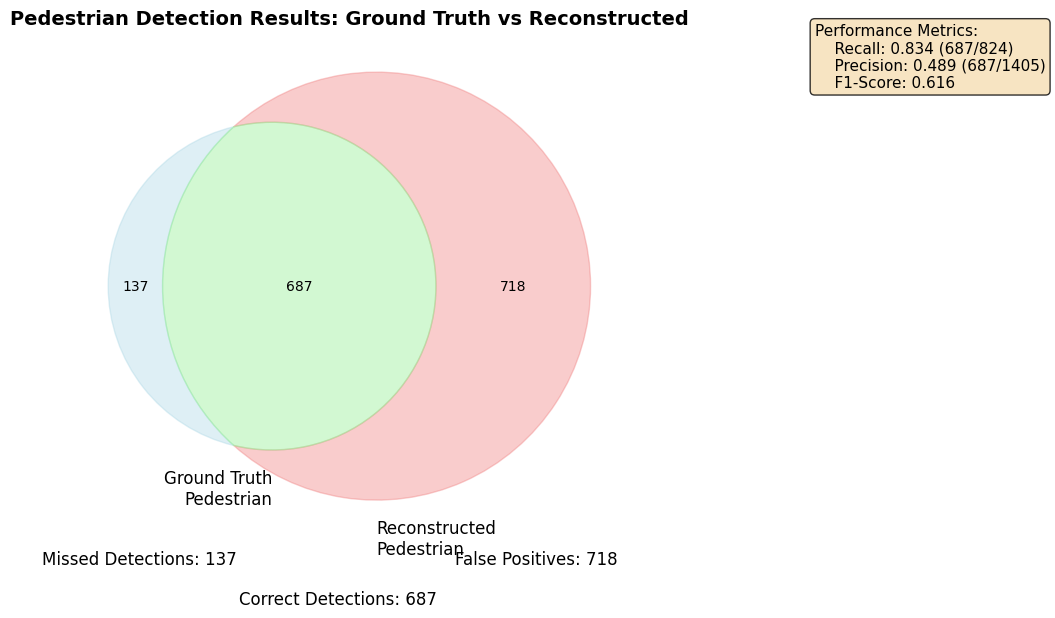

=== Pedestrian Detection Summary ===
Total images with Pedestrian in GT: 824
Total images with Pedestrian detected: 1405
Correctly detected: 687
Missed detections: 137
False positives: 718
Recall: 0.834
Precision: 0.489
F1-Score: 0.616


/tmp/ipykernel_1030953/1533358040.py:15: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  lambda x: isinstance(x, (np.ndarray, list, tuple, set)) and class_name in x


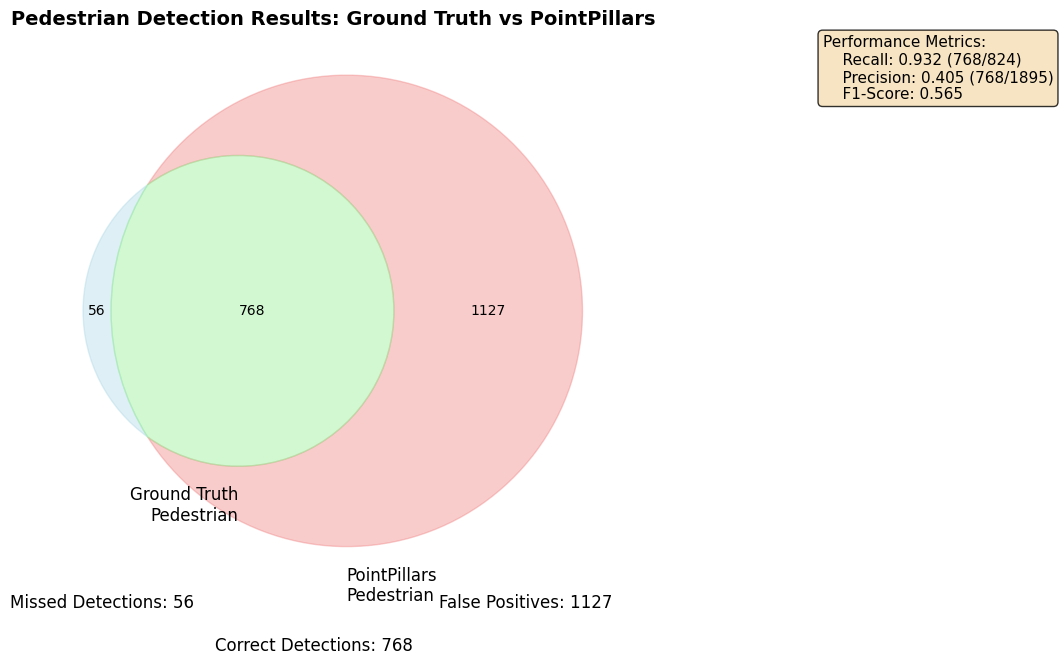

=== Pedestrian Detection Summary ===
Total images with Pedestrian in GT: 824
Total images with Pedestrian detected: 1895
Correctly detected: 768
Missed detections: 56
False positives: 1127
Recall: 0.932
Precision: 0.405
F1-Score: 0.565


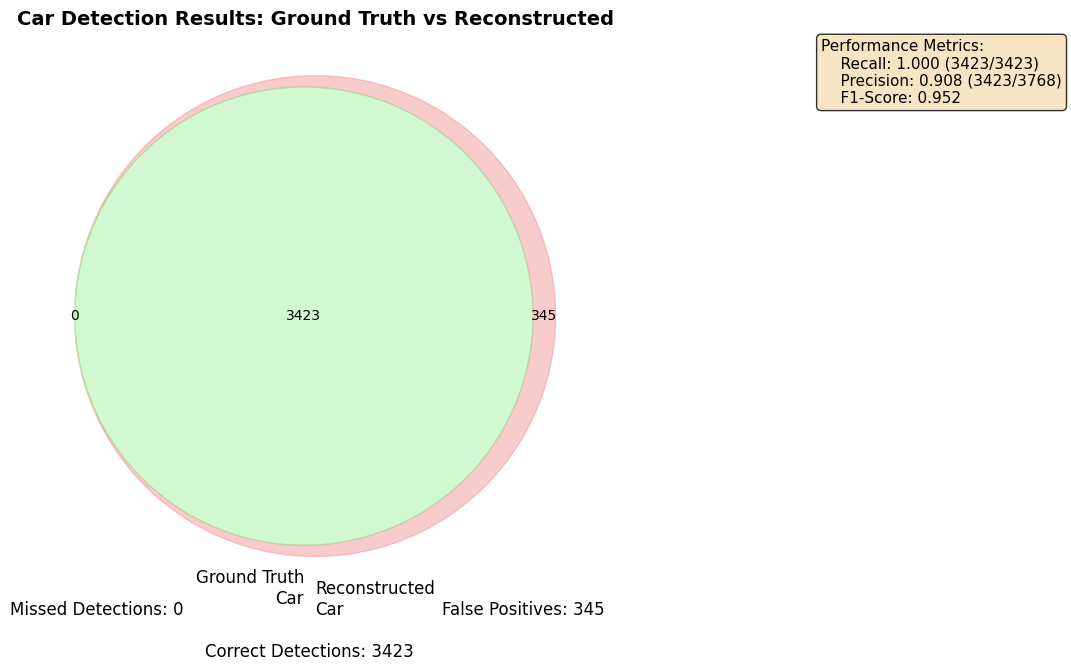

=== Car Detection Summary ===
Total images with Car in GT: 3423
Total images with Car detected: 3768
Correctly detected: 3423
Missed detections: 0
False positives: 345
Recall: 1.000
Precision: 0.908
F1-Score: 0.952


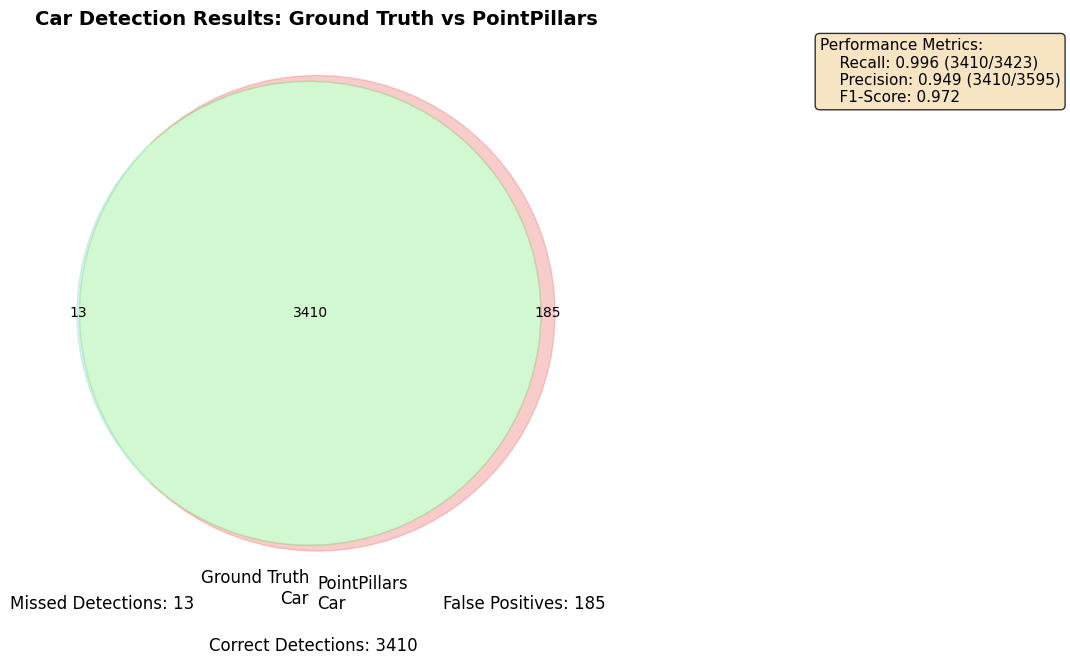

=== Car Detection Summary ===
Total images with Car in GT: 3423
Total images with Car detected: 3595
Correctly detected: 3410
Missed detections: 13
False positives: 185
Recall: 0.996
Precision: 0.949
F1-Score: 0.972


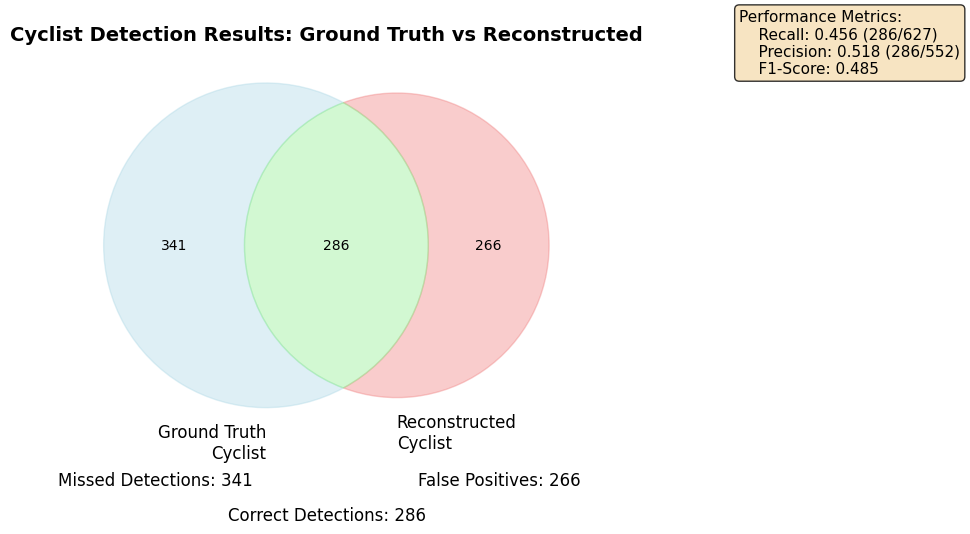

=== Cyclist Detection Summary ===
Total images with Cyclist in GT: 627
Total images with Cyclist detected: 552
Correctly detected: 286
Missed detections: 341
False positives: 266
Recall: 0.456
Precision: 0.518
F1-Score: 0.485


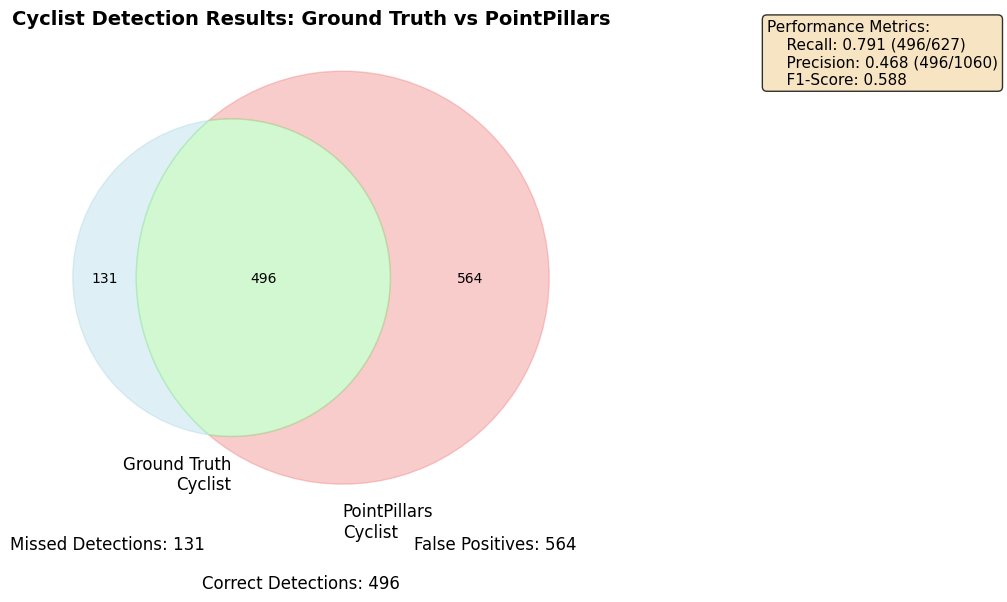

=== Cyclist Detection Summary ===
Total images with Cyclist in GT: 627
Total images with Cyclist detected: 1060
Correctly detected: 496
Missed detections: 131
False positives: 564
Recall: 0.791
Precision: 0.468
F1-Score: 0.588


In [14]:
venn_diagram(merged_df, 'name_gt', 'name_eval', 'Pedestrian')
venn_diagram(merged_df, 'name_gt', 'name_pp', 'Pedestrian')
venn_diagram(merged_df, 'name_gt', 'name_eval', 'Car')
venn_diagram(merged_df, 'name_gt', 'name_pp', 'Car')
venn_diagram(merged_df, 'name_gt', 'name_eval', 'Cyclist')
venn_diagram(merged_df, 'name_gt', 'name_pp', 'Cyclist')

In [15]:
all_names = merged_df['name_gt'].apply(pd.Series).stack().dropna()
all_names.value_counts()

Car               14381
DontCare           5896
Pedestrian         2280
Van                1617
Cyclist             893
Misc                636
Truck               606
Tram                287
Person_sitting      166
Name: count, dtype: int64